In [43]:
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_curve, auc
from sklearn.preprocessing import MinMaxScaler
import gc

import tensorflow as tf
import optuna

import warnings
warnings.filterwarnings('ignore')

In [44]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

# Загрузка данных

In [45]:
df = yf.download(['RUB=X', 'EURRUB=X', 'GBPRUB=X', 'GC=F'], start='2000-01-01', multi_level_index=False, auto_adjust=False)['Close'].reset_index().dropna()
df.columns = ['Date', 'eur_rub', 'gbp_rub', 'gold', 'usd_rub']

df = df[df['usd_rub'] > 10]

df

[*********************100%***********************]  4 of 4 completed


,Date,eur_rub,gbp_rub,gold,usd_rub
864,2004-02-13,36.470001,53.591999,410.299988,28.440001
898,2004-04-01,34.990002,52.884998,427.799988,28.487801
981,2004-07-27,35.070000,52.995998,387.000000,29.090000
1131,2005-02-22,36.689999,53.369999,434.500000,27.932301
1451,2006-05-16,33.234001,48.801998,691.500000,26.993999
...,...,...,...,...,...
6651,2026-04-27,87.239998,100.717278,4675.399902,74.525246
6652,2026-04-28,87.772202,101.352310,4591.500000,74.866417
6653,2026-04-29,88.254601,101.866280,4545.200195,75.322472
6654,2026-04-30,87.336403,100.819191,4614.700195,74.745834


<Axes: xlabel='Date'>

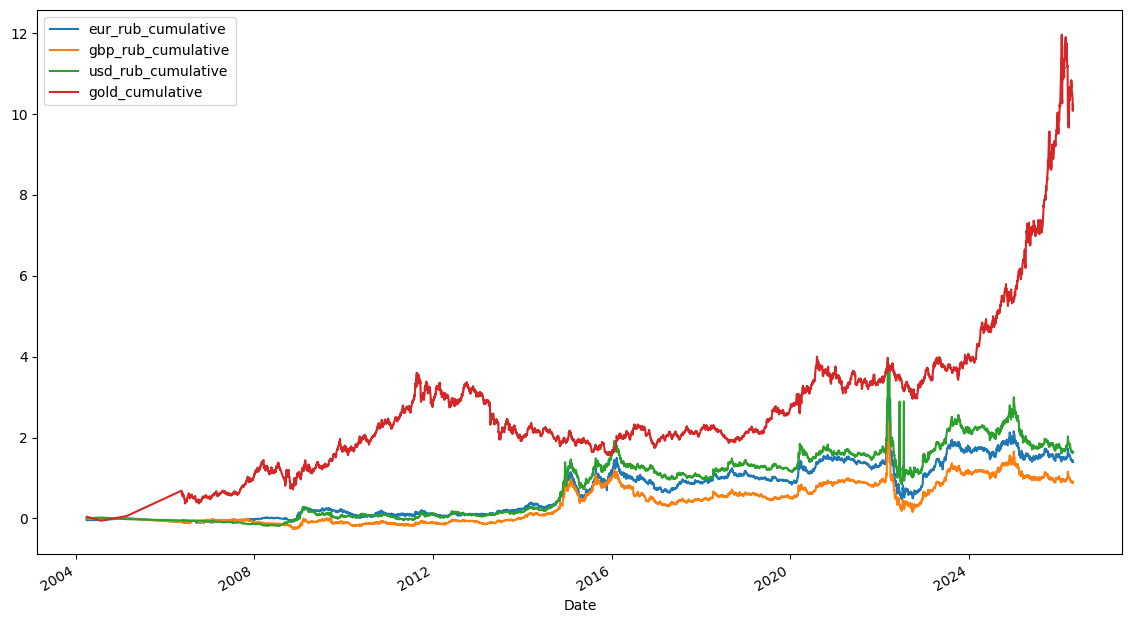

In [46]:
df['eur_rub_cumulative'] = (1 + df['eur_rub'].pct_change()).cumprod() - 1
df['gbp_rub_cumulative'] = (1 + df['gbp_rub'].pct_change()).cumprod() - 1
df['usd_rub_cumulative'] = (1 + df['usd_rub'].pct_change()).cumprod() - 1
df['gold_cumulative'] = (1 + df['gold'].pct_change()).cumprod() - 1

df.set_index('Date')[['eur_rub_cumulative', 'gbp_rub_cumulative', 'usd_rub_cumulative', 'gold_cumulative']].plot(figsize=[14, 8])

In [47]:
del df['eur_rub_cumulative'], df['gbp_rub_cumulative'], df['usd_rub_cumulative'], df['gold_cumulative']

# Признаки и таргет

In [48]:
data = df.melt(
    id_vars=['Date'],
    var_name='ticker',
    value_name='price'
).sort_values(['Date', 'ticker']).reset_index(drop=True)

for lag in range(1, 22):
    data[f'chg_{lag}d'] = data.groupby('ticker')['price'].transform(lambda x: x.pct_change(lag))

data['perf_1d'] = data.groupby('ticker')['price'].transform(lambda x: x.shift(-1) / x - 1)
data['perf_5d'] = data.groupby('ticker')['price'].transform(lambda x: x.shift(-5) / x - 1)
data['perf_10d'] = data.groupby('ticker')['price'].transform(lambda x: x.shift(-10) / x - 1)
data['perf_20d'] = data.groupby('ticker')['price'].transform(lambda x: x.shift(-20) / x - 1)

data['target_1'] = np.where(data['perf_1d'] > 0, 1, 0)
data['target_2'] = np.where(data['perf_5d'] > 0, 1, 0)
data['target_3'] = np.where(data['perf_10d'] > 0, 1, 0)
data['target_4'] = np.where(data['perf_20d'] > 0, 1, 0)

del data['perf_1d'], data['perf_5d'], data['perf_10d'], data['perf_20d']
data = data.dropna()

data

,Date,ticker,price,chg_1d,chg_2d,chg_3d,chg_4d,chg_5d,chg_6d,chg_7d,...,chg_16d,chg_17d,chg_18d,chg_19d,chg_20d,chg_21d,target_1,target_2,target_3,target_4
84,2006-06-09,eur_rub,32.791000,-0.039232,-0.045469,-0.046219,-0.048654,-0.007116,-0.055014,-0.051872,...,-0.044969,-0.013330,-0.106269,-0.064984,-0.062847,-0.100877,0,0,0,1
85,2006-06-09,gbp_rub,47.730999,-0.040139,-0.042277,-0.043505,-0.045609,-0.007981,-0.055897,-0.055243,...,-0.058857,-0.021946,-0.105659,-0.099347,-0.097457,-0.109363,1,1,0,1
86,2006-06-09,gold,608.200012,-0.001478,-0.030603,-0.033683,-0.054415,-0.042958,-0.030911,-0.053385,...,-0.119189,-0.120463,0.399770,0.571576,0.421692,0.482330,0,0,0,1
87,2006-06-09,usd_rub,27.040001,0.001927,0.007076,0.008579,0.012355,0.010463,-0.001846,0.001259,...,0.003340,0.001704,-0.031945,-0.070471,-0.050822,-0.049226,1,0,1,0
88,2006-06-12,eur_rub,32.693001,-0.002989,-0.042104,-0.048322,-0.049069,-0.051497,-0.010083,-0.057839,...,-0.013220,-0.047823,-0.016279,-0.108940,-0.067779,-0.065647,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19943,2026-04-30,usd_rub,74.745834,-0.007656,-0.001611,0.002960,-0.014845,-0.004682,-0.004954,-0.002695,...,-0.046875,-0.067830,-0.070394,-0.069114,-0.080573,-0.080493,1,0,0,0
19944,2026-05-01,eur_rub,88.169998,0.009545,-0.000959,0.004532,0.010660,-0.005348,0.003007,-0.000593,...,-0.037162,-0.037967,-0.047252,-0.047252,-0.052620,-0.062871,0,0,0,0
19945,2026-05-01,gbp_rub,102.220001,0.013894,0.003472,0.008561,0.014920,0.000500,0.008351,0.007191,...,-0.028276,-0.027402,-0.036712,-0.035878,-0.042985,-0.050648,0,0,0,0
19946,2026-05-01,gold,4589.000000,-0.005569,0.009636,-0.000544,-0.018480,-0.028228,-0.024675,-0.030322,...,-0.042402,-0.033793,-0.014623,-0.014559,-0.013437,-0.040600,0,0,0,0


In [49]:
data['target_1'].value_counts(), data['target_2'].value_counts(), data['target_3'].value_counts(), data['target_4'].value_counts()

(target_1
 1    10011
 0     9853
 Name: count, dtype: int64,
 target_2
 1    10205
 0     9659
 Name: count, dtype: int64,
 target_3
 1    10211
 0     9653
 Name: count, dtype: int64,
 target_4
 1    10328
 0     9536
 Name: count, dtype: int64)

In [50]:
targets = [
    'target_1', 
    'target_2', 
    'target_3', 
    'target_4'
]

features = [f'chg_{lag}d' for lag in range(1, 22)]
features

['chg_1d',
 'chg_2d',
 'chg_3d',
 'chg_4d',
 'chg_5d',
 'chg_6d',
 'chg_7d',
 'chg_8d',
 'chg_9d',
 'chg_10d',
 'chg_11d',
 'chg_12d',
 'chg_13d',
 'chg_14d',
 'chg_15d',
 'chg_16d',
 'chg_17d',
 'chg_18d',
 'chg_19d',
 'chg_20d',
 'chg_21d']

# Разделение выборки (для валидации)

**Подбор гиперпараметров, нужна валидационная выборка**

In [51]:
train = data[data['Date'] < '2017-01-01']
validation = data[(data['Date'] >= '2017-01-01') & (data['Date'] <= '2021-01-01')]
test = data[data['Date'] > '2021-01-01']

train.shape, validation.shape, test.shape

((10500, 28), (4012, 28), (5352, 28))

In [52]:
x_train = train[features].to_numpy()
x_val = validation[features].to_numpy()
x_test = test[features].to_numpy()

y_train = train[targets].to_numpy()
y_val = validation[targets].to_numpy()
y_test = test[targets].to_numpy()

x_train.shape, y_train.shape, x_val.shape, y_val.shape, x_test.shape, y_test.shape

((10500, 21), (10500, 4), (4012, 21), (4012, 4), (5352, 21), (5352, 4))

# Базовый scaler для LSTM - MinMax

**MinMax лучше всего подходит для рекуррентных нейронных сетей, это уже доказано и показано множество раз, не имеет смысла подбирать другой препроцессор**

In [58]:
scaler = MinMaxScaler()

x_train_scaled = scaler.fit_transform(np.concatenate((x_train, x_val)))
x_test_scaled = scaler.transform(x_test).clip(-1, 1)

x_train_scaled.shape, x_test_scaled.shape

((14512, 21), (5352, 21))

In [59]:
EPOCHS = 100
BATCH_SIZE = 256

# Функция LSTM

**Функция создания и обучения LSTM с выведенными гиперпараметрами, как аргементами, для легкой валидации и настройки**

In [60]:
def lstm_model(
    x_train,
    y_train,
    x_val=None,
    y_val=None,
    n_units=64,
    num_layers=2,
    learning_rate=3e-4,
    batch_size=64,
    dropout=0.2,
    epochs=100,
    patience=3,
    loss='binary_crossentropy',
    verbose=1
):

    seq_len = x_train.shape[1]
    input_size = x_train.shape[2]

    inputs = tf.keras.Input(shape=(seq_len, input_size))

    x = inputs

    # LSTM layers
    for i in range(num_layers):
        return_seq = (i < num_layers - 1)

        lstm_layer = tf.keras.layers.LSTM(
            units=n_units,
            dropout=dropout,
            return_sequences=return_seq,
            return_state=False
        )

        x = lstm_layer(x)

    outputs = tf.keras.layers.Dense(4, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate),
        loss=loss,
        metrics=['accuracy']
    )

    has_validation = (x_val is not None and y_val is not None)
    
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss' if has_validation else 'loss',
            patience=patience,
            restore_best_weights=True
        )
    ]

    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val) if has_validation else None,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=verbose
    )

    return model, history

# Функция создания последовательности

**Генерация последовательности, для временных рядов это лаги**

In [61]:
x_train_seq = x_train_scaled.reshape(x_train_scaled.shape[0], 1, x_train_scaled.shape[1])
x_test_seq = x_test_scaled.reshape(x_test_scaled.shape[0], 1, x_test_scaled.shape[1])

y_train_seq = np.concatenate((y_train, y_val))
y_test_seq = y_test.copy()

x_train_seq.shape, y_train_seq.shape, x_test_seq.shape, y_test_seq.shape

((14512, 1, 21), (14512, 4), (5352, 1, 21), (5352, 4))

In [62]:
model, history = lstm_model(
    x_train=x_train_seq,
    y_train=y_train_seq,
    x_val=None,
    y_val=None,
    n_units=64,
    num_layers=2,
    learning_rate=3e-4,
    batch_size=BATCH_SIZE,
    dropout=0.2,
    epochs=EPOCHS,
    patience=5,
    loss='binary_crossentropy',
    verbose=1
)

Epoch 1/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2268 - loss: 0.6929
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0636 - loss: 0.6928
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0600 - loss: 0.6928
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0697 - loss: 0.6927
Epoch 5/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0628 - loss: 0.6927
Epoch 6/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0617 - loss: 0.6928
Epoch 7/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0750 - loss: 0.6927
Epoch 8/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0717 - loss: 0.6928
Epoch 9/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0797 - loss: 0.6927


In [63]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 1, 21)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 1, 64)          │        22,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165,902 (648.06 KB)

 Trainable params: 55,300 (216.02 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 110,602 (432.04 KB)

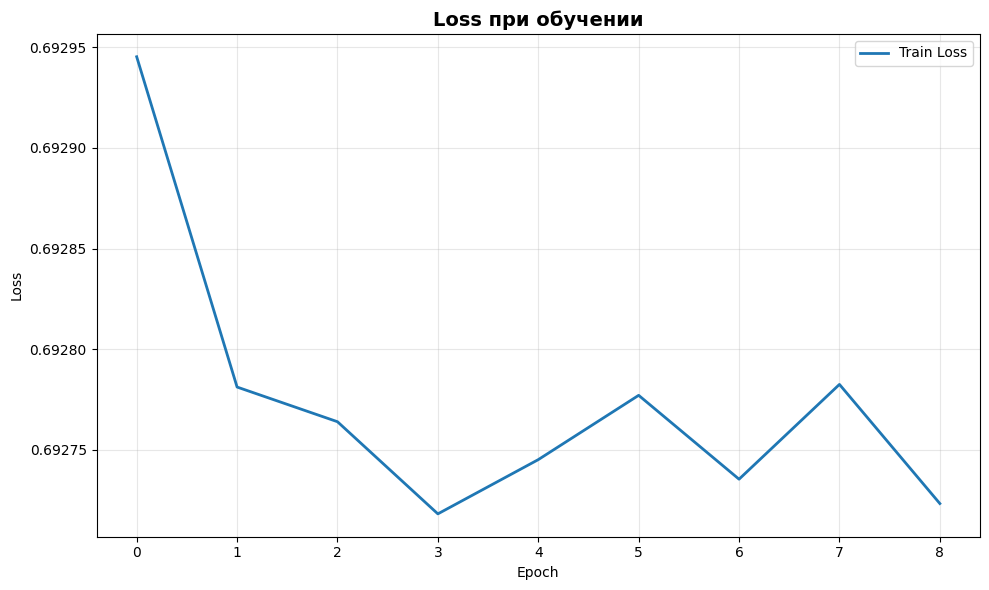

In [64]:
# ================================================================
# Визуализация процесса обучения
# ================================================================

plt.figure(figsize=(10, 6))

# График потерь (Loss)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.title('Loss при обучении', fontweight='bold', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [65]:
# ================================================================
# Прогноз на тестовой выборке
# ================================================================

y_pred = model.predict(x_test_seq, verbose=1, batch_size=BATCH_SIZE)

y_pred_classes = (y_pred > 0.5).astype(int)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [66]:
# ================================================================
# Метрики ошибок на тестовой выборке
# ================================================================

print(classification_report(y_test_seq, y_pred_classes))

              precision    recall  f1-score   support

           0       0.50      1.00      0.67      2688
           1       0.51      1.00      0.68      2734
           2       0.51      1.00      0.67      2704
           3       0.53      1.00      0.69      2834

   micro avg       0.51      1.00      0.68     10960
   macro avg       0.51      1.00      0.68     10960
weighted avg       0.51      1.00      0.68     10960
 samples avg       0.51      0.81      0.60     10960



# Валидация LSTM (подбор гиперпараметров), tuning

**Создаем пространство гиперпараметров и выбираем наилучшую конфигурацию с помощью ччисленной оптимизации Optuna**

In [69]:
scaler = MinMaxScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.transform(x_val).clip(-1, 1)

x_train_seq = x_train_scaled.reshape(x_train_scaled.shape[0], 1, x_train_scaled.shape[1])
x_val_seq = x_val_scaled.reshape(x_val_scaled.shape[0], 1, x_val_scaled.shape[1])

y_train_seq = y_train.copy()
y_val_seq = y_val.copy()

x_train_seq.shape, y_train_seq.shape, x_val_seq.shape, y_val_seq.shape

((10500, 1, 21), (10500, 4), (4012, 1, 21), (4012, 4))

In [70]:
def objective(trial):

    n_units = trial.suggest_int('n_units', 64, 512, step=64)
    num_lstm_layers = trial.suggest_int('num_lstm_layers', 1, 4, step=1)
    dropout = trial.suggest_float('dropout', 0, 0.5, step=0.1)
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-3, log=True)

    model, history = lstm_model(
        x_train=x_train_seq,
        y_train=y_train_seq,
        x_val=x_val_seq,
        y_val=y_val_seq,
        n_units=n_units,
        num_layers=num_lstm_layers,
        learning_rate=learning_rate,
        batch_size=BATCH_SIZE,
        dropout=dropout,
        epochs=EPOCHS,
        patience=5,
        loss='binary_crossentropy',
        verbose=0
    )

    y_pred = model.predict(x_val_seq, batch_size=BATCH_SIZE, verbose=0)

    y_pred_classes = (y_pred > 0.5).astype(int)

    score = f1_score(y_val_seq, y_pred_classes, average='macro')

    del model, history, y_pred, y_pred_classes
    
    gc.collect()
    tf.keras.backend.clear_session()

    return score

In [71]:
sampler = optuna.samplers.TPESampler(
    n_startup_trials=5,
    multivariate=True,
    group=True,
    constant_liar=True
)

study = optuna.create_study(direction='maximize', sampler=sampler)

[I 2026-05-01 17:21:45,898] A new study created in memory with name: no-name-6cb5f624-1c5c-427b-b8c9-bc9d360d2cf2


In [72]:
study.optimize(
    objective,
    n_trials=200,
    show_progress_bar=True,
    gc_after_trial=True,
    n_jobs=1
)

  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-05-01 17:22:05,346] Trial 0 finished with value: 0.6836342977130198 and parameters: {'n_units': 320, 'num_lstm_layers': 4, 'dropout': 0.0, 'learning_rate': 2.1865807509576362e-05}. Best is trial 0 with value: 0.6836342977130198.
[I 2026-05-01 17:22:15,274] Trial 1 finished with value: 0.6836342977130198 and parameters: {'n_units': 320, 'num_lstm_layers': 4, 'dropout': 0.0, 'learning_rate': 0.00031582738676560915}. Best is trial 0 with value: 0.6836342977130198.
[I 2026-05-01 17:22:18,865] Trial 2 finished with value: 0.5734046826904599 and parameters: {'n_units': 128, 'num_lstm_layers': 1, 'dropout': 0.1, 'learning_rate': 0.00021696633112139446}. Best is trial 0 with value: 0.6836342977130198.
[I 2026-05-01 17:22:24,783] Trial 3 finished with value: 0.6836342977130198 and parameters: {'n_units': 192, 'num_lstm_layers': 1, 'dropout': 0.2, 'learning_rate': 0.00013300556778162757}. Best is trial 0 with value: 0.6836342977130198.
[I 2026-05-01 17:22:54,010] Trial 4 finished with va

In [73]:
trials_df = study.trials_dataframe()
trials_df = trials_df.sort_values('value', ascending=False)
trials_df.to_csv('tuning.csv')
trials_df

,number,value,datetime_start,datetime_complete,duration,params_dropout,params_learning_rate,params_n_units,params_num_lstm_layers,system_attrs_tpe:relative_params:0,state
33,33,0.683749,2026-05-01 17:27:56.037796,2026-05-01 17:28:03.223315,0 days 00:00:07.185519,0.1,0.000127,384,1,"{""dropout"": 0.1, ""learning_rate"": 0.0001267646...",COMPLETE
90,90,0.683747,2026-05-01 17:41:52.375188,2026-05-01 17:42:02.054532,0 days 00:00:09.679344,0.2,0.000070,128,1,"{""dropout"": 0.2, ""learning_rate"": 7.0422867535...",COMPLETE
20,20,0.683690,2026-05-01 17:26:19.781464,2026-05-01 17:26:23.806381,0 days 00:00:04.024917,0.0,0.000134,384,1,"{""dropout"": 0.0, ""learning_rate"": 0.0001344658...",COMPLETE
18,18,0.683680,2026-05-01 17:26:10.987605,2026-05-01 17:26:15.368001,0 days 00:00:04.380396,0.0,0.000108,448,1,"{""dropout"": 0.0, ""learning_rate"": 0.0001079948...",COMPLETE
104,104,0.683662,2026-05-01 17:44:19.690490,2026-05-01 17:44:26.841927,0 days 00:00:07.151437,0.4,0.000177,128,1,"{""dropout"": 0.4, ""learning_rate"": 0.0001773130...",COMPLETE
...,...,...,...,...,...,...,...,...,...,...,...
88,88,0.523877,2026-05-01 17:41:40.068051,2026-05-01 17:41:44.968428,0 days 00:00:04.900377,0.1,0.000191,320,1,"{""dropout"": 0.1, ""learning_rate"": 0.0001910518...",COMPLETE
55,55,0.517513,2026-05-01 17:31:21.395987,2026-05-01 17:31:27.866633,0 days 00:00:06.470646,0.1,0.000075,128,2,"{""dropout"": 0.1, ""learning_rate"": 7.5135453869...",COMPLETE
112,112,0.515559,2026-05-01 17:45:18.532918,2026-05-01 17:45:25.849224,0 days 00:00:07.316306,0.3,0.000181,128,2,"{""dropout"": 0.30000000000000004, ""learning_rat...",COMPLETE
141,141,0.515314,2026-05-01 17:53:23.116206,2026-05-01 17:53:33.243154,0 days 00:00:10.126948,0.0,0.000062,512,3,"{""dropout"": 0.0, ""learning_rate"": 6.2279701379...",COMPLETE


In [74]:
print("Лучшие параметры:", study.best_params)
print("Лучший value:", study.best_value)

Лучшие параметры: {'n_units': 384, 'num_lstm_layers': 1, 'dropout': 0.1, 'learning_rate': 0.0001267646859981189}
Лучший value: 0.6837492051555133


# Тестовая выборка, выбираем наилучшую комбинацию с тюнинга

**Выбираем оптимальные гиперпараметры из Optuna**

In [121]:
N_UNITS = 384
NUM_LSTM_LAYERS = 1
DROPOUT = 0.1
LEARNING_RATE = 0.0001267646859981189

In [122]:
scaler = MinMaxScaler()

x_train_scaled = scaler.fit_transform(np.concatenate((x_train, x_val)))
x_test_scaled = scaler.transform(x_test).clip(-1, 1)

x_train_seq = x_train_scaled.reshape(x_train_scaled.shape[0], 1, x_train_scaled.shape[1])
x_test_seq = x_test_scaled.reshape(x_test_scaled.shape[0], 1, x_test_scaled.shape[1])

y_train_seq = (np.concatenate((y_train, y_val))).copy()
y_test_seq = y_test.copy()

x_train_seq.shape, y_train_seq.shape, x_test_seq.shape, y_test_seq.shape

((14512, 1, 21), (14512, 4), (5352, 1, 21), (5352, 4))

In [123]:
model, history = lstm_model(
    x_train=x_train_seq,
    y_train=y_train_seq,
    x_val=None,
    y_val=None,
    n_units=N_UNITS,
    num_layers=NUM_LSTM_LAYERS,
    learning_rate=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    dropout=DROPOUT,
    epochs=EPOCHS,
    patience=5,
    loss='binary_crossentropy',
    verbose=1
)

Epoch 1/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0892 - loss: 0.6930
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0720 - loss: 0.6928
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0581 - loss: 0.6928
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0690 - loss: 0.6928
Epoch 5/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0813 - loss: 0.6927
Epoch 6/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0713 - loss: 0.6927
Epoch 7/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0657 - loss: 0.6927
Epoch 8/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0744 - loss: 0.6927
Epoch 9/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0582 - loss: 0.6926
Epoch 10/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1312 - loss: 0.6927
Epoch 11/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0590 - loss: 0.6926
Epoch 12/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy:

In [124]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 1, 21)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 384)            │       623,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,540 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,875,470 (7.15 MB)

 Trainable params: 625,156 (2.38 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,250,314 (4.77 MB)

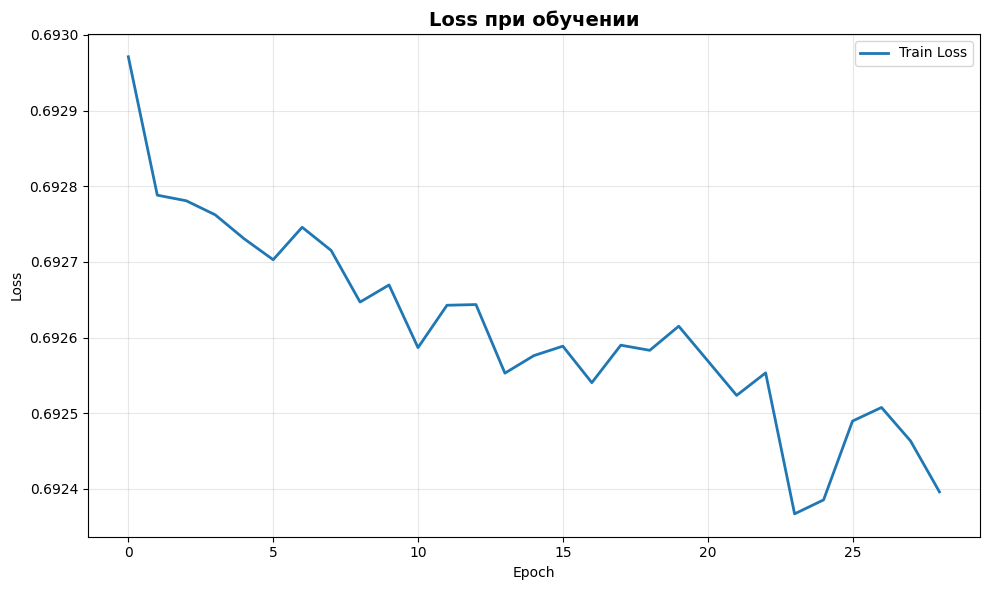

In [125]:
# ================================================================
# Визуализация процесса обучения
# ================================================================

plt.figure(figsize=(10, 6))

# График потерь (Loss)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.title('Loss при обучении', fontweight='bold', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [126]:
# ================================================================
# Прогноз на тестовой выборке
# ================================================================

y_pred = model.predict(x_test_seq, verbose=1, batch_size=BATCH_SIZE)
y_pred_classes = (y_pred > 0.5).astype("int32")

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [127]:
# ================================================================
# Метрики ошибок на тестовой выборке
# ================================================================

print(classification_report(y_test_seq, y_pred_classes))

              precision    recall  f1-score   support

           0       0.50      0.95      0.66      2688
           1       0.52      0.98      0.68      2734
           2       0.51      0.98      0.67      2704
           3       0.54      0.99      0.70      2834

   micro avg       0.52      0.98      0.68     10960
   macro avg       0.52      0.98      0.68     10960
weighted avg       0.52      0.98      0.68     10960
 samples avg       0.50      0.78      0.58     10960



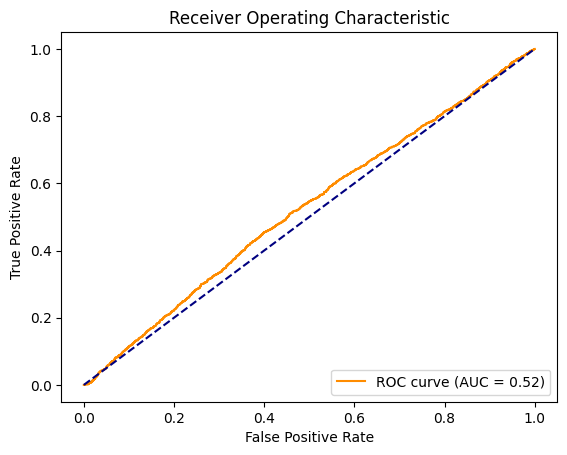

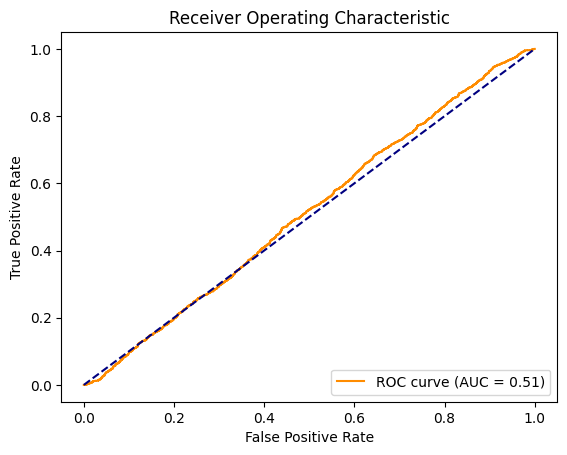

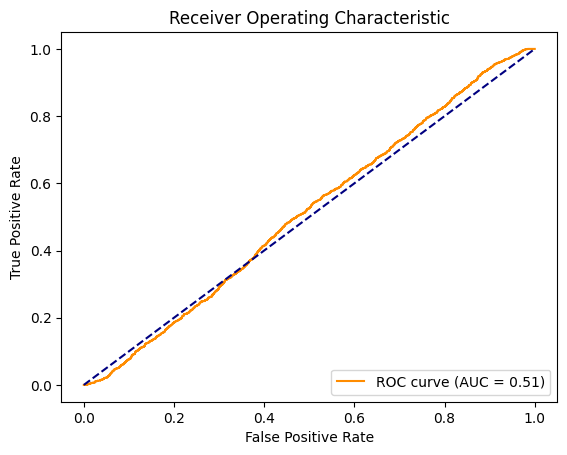

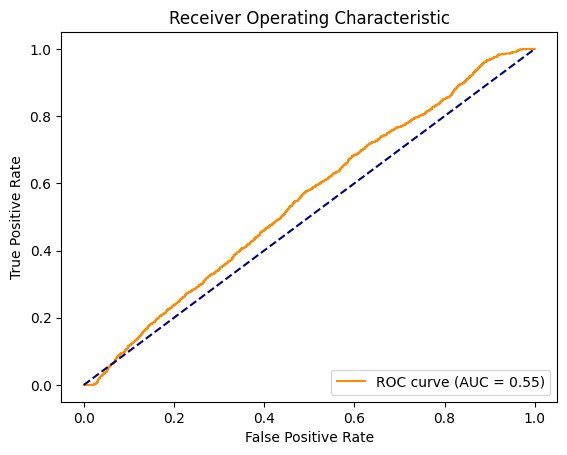

In [128]:
# ================================================================
# ROC-AUC
# ================================================================

for i in range(4):
    fpr, tpr, thresholds = roc_curve(y_test_seq[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()

In [140]:
test['prediction_1'] = y_pred_classes[:, 0]
test['prediction_5'] = y_pred_classes[:, 1]
test['prediction_10'] = y_pred_classes[:, 2]
test['prediction_20'] = y_pred_classes[:, 3]

test['prob_1'] = y_pred[:, 0]
test['prob_5'] = y_pred[:, 1]
test['prob_10'] = y_pred[:, 2]
test['prob_20'] = y_pred[:, 3]

test

,Date,ticker,price,chg_1d,chg_2d,chg_3d,chg_4d,chg_5d,chg_6d,chg_7d,...,prob_1,prob_2,prob_3,prob_4,prediction_5,prediction_10,prediction_20,prob_5,prob_10,prob_20
14596,2021-01-04,eur_rub,91.172600,-0.003268,0.004844,0.009635,0.012163,-0.003444,-0.014425,-0.004925,...,0.505776,0.516164,0.518707,0.516419,1,1,1,0.516164,0.518707,0.516419
14597,2021-01-04,gbp_rub,101.239967,-0.002112,0.013126,0.017802,0.023049,-0.000693,-0.004186,0.009564,...,0.505031,0.515966,0.518820,0.516964,1,1,1,0.515966,0.518820,0.516964
14598,2021-01-04,gold,1944.699951,0.027257,0.028398,0.034580,0.035958,0.034470,0.037339,0.041841,...,0.504822,0.517160,0.520634,0.518915,1,1,1,0.517160,0.520634,0.518915
14599,2021-01-04,usd_rub,74.127403,-0.005295,0.001432,0.002663,0.002333,-0.011901,-0.023072,-0.005686,...,0.505123,0.514728,0.517273,0.514864,1,1,1,0.514728,0.517273,0.514864
14600,2021-01-05,eur_rub,91.278198,0.001158,-0.002113,0.006008,0.010805,0.013335,-0.002290,-0.013283,...,0.506962,0.517247,0.519265,0.517063,1,1,1,0.517247,0.519265,0.517063
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19943,2026-04-30,usd_rub,74.745834,-0.007656,-0.001611,0.002960,-0.014845,-0.004682,-0.004954,-0.002695,...,0.500900,0.507373,0.508859,0.508499,1,1,1,0.507373,0.508859,0.508499
19944,2026-05-01,eur_rub,88.169998,0.009545,-0.000959,0.004532,0.010660,-0.005348,0.003007,-0.000593,...,0.501423,0.508751,0.510365,0.509480,1,1,1,0.508751,0.510365,0.509480
19945,2026-05-01,gbp_rub,102.220001,0.013894,0.003472,0.008561,0.014920,0.000500,0.008351,0.007191,...,0.501397,0.509339,0.511298,0.510424,1,1,1,0.509339,0.511298,0.510424
19946,2026-05-01,gold,4589.000000,-0.005569,0.009636,-0.000544,-0.018480,-0.028228,-0.024675,-0.030322,...,0.504405,0.510917,0.512289,0.509251,1,1,1,0.510917,0.512289,0.509251


Актив: eur_rub
Горизонт прогноза: t+1


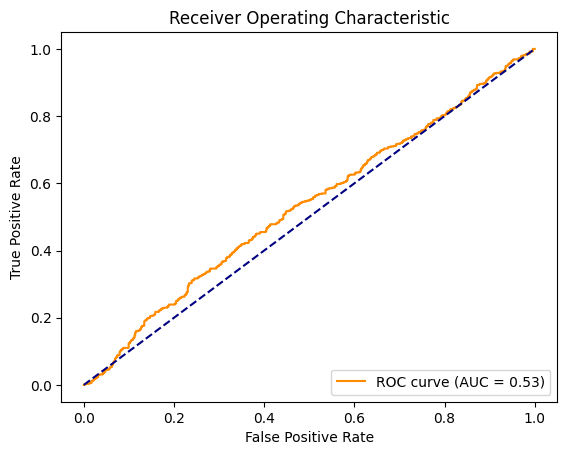

Актив: eur_rub
Горизонт прогноза: t+5


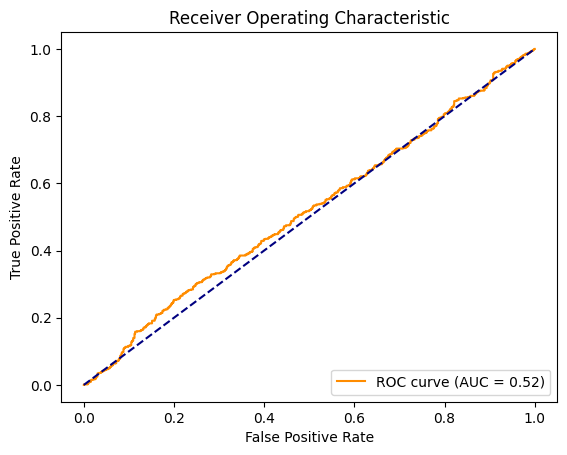

Актив: eur_rub
Горизонт прогноза: t+10


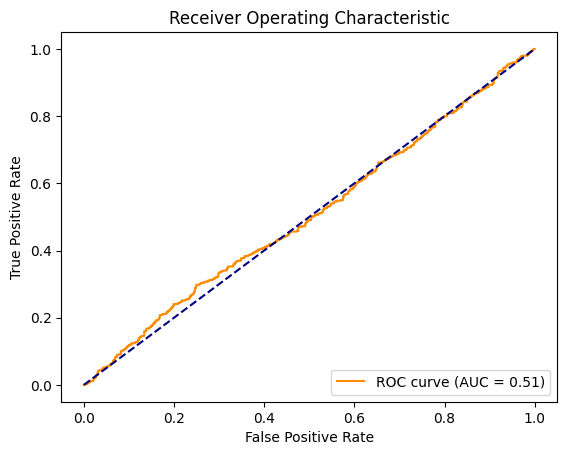

Актив: eur_rub
Горизонт прогноза: t+20


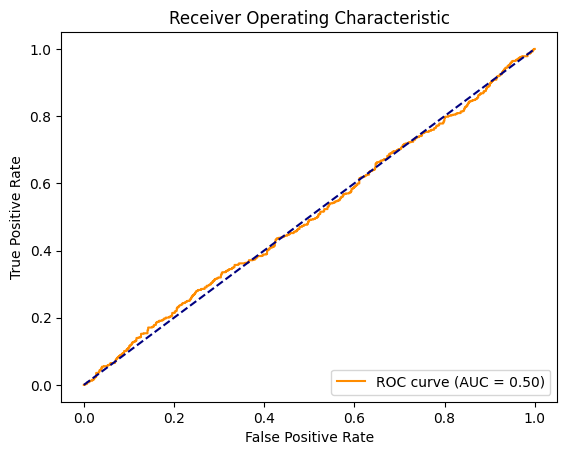

Актив: gbp_rub
Горизонт прогноза: t+1


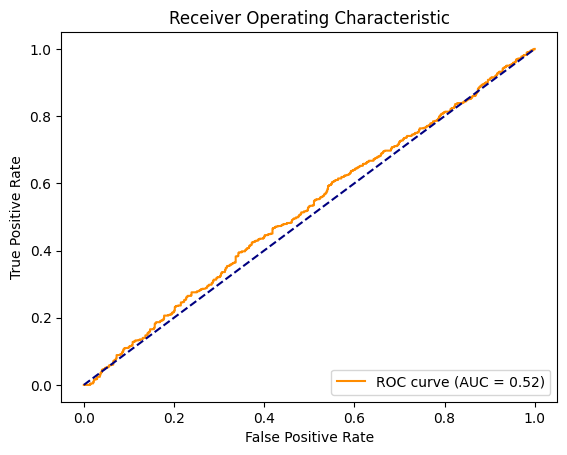

Актив: gbp_rub
Горизонт прогноза: t+5


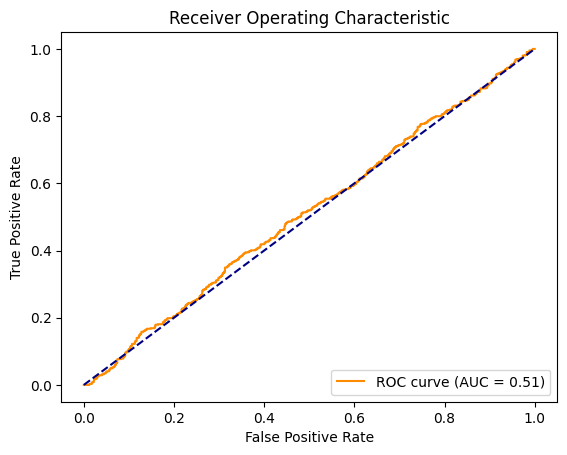

Актив: gbp_rub
Горизонт прогноза: t+10


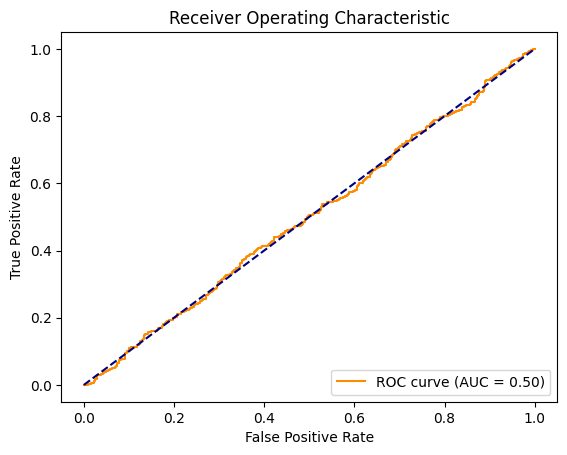

Актив: gbp_rub
Горизонт прогноза: t+20


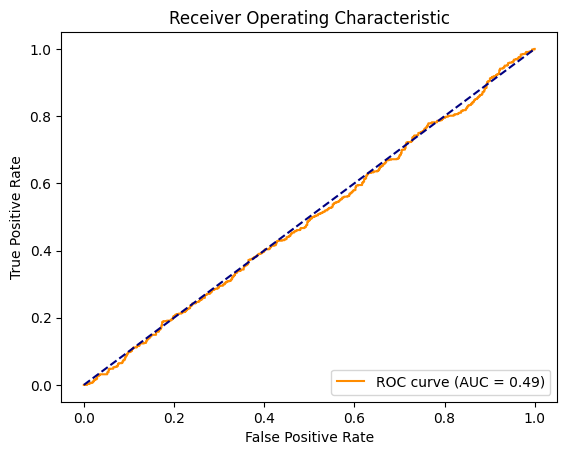

Актив: gold
Горизонт прогноза: t+1


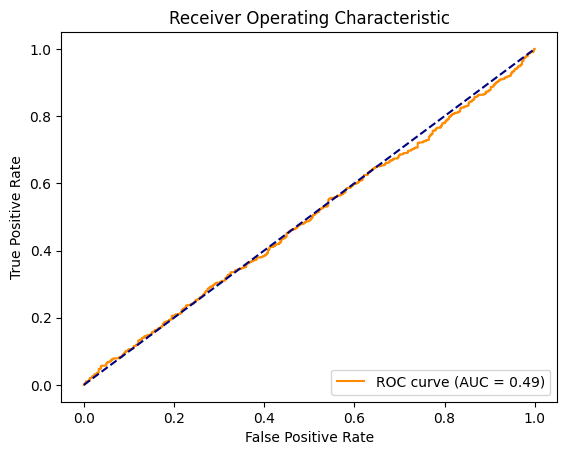

Актив: gold
Горизонт прогноза: t+5


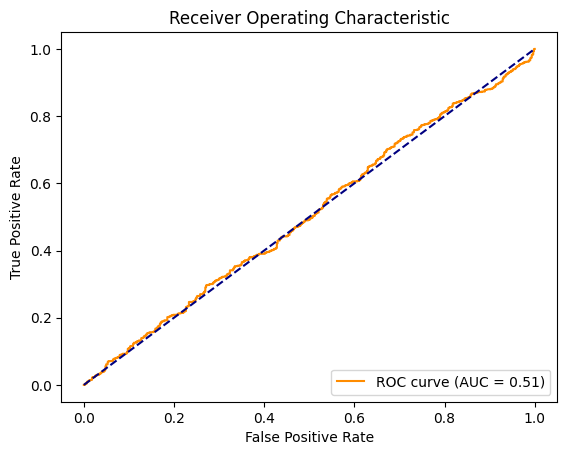

Актив: gold
Горизонт прогноза: t+10


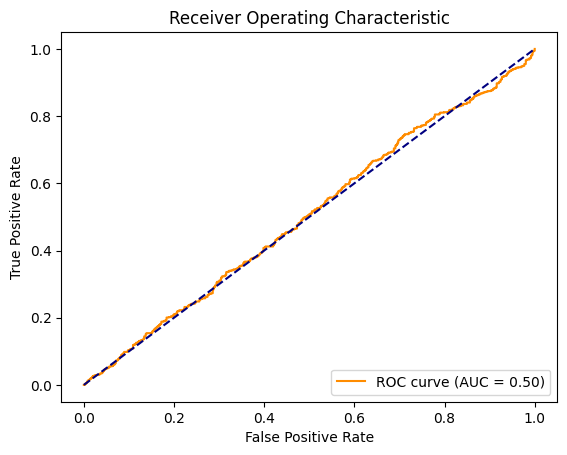

Актив: gold
Горизонт прогноза: t+20


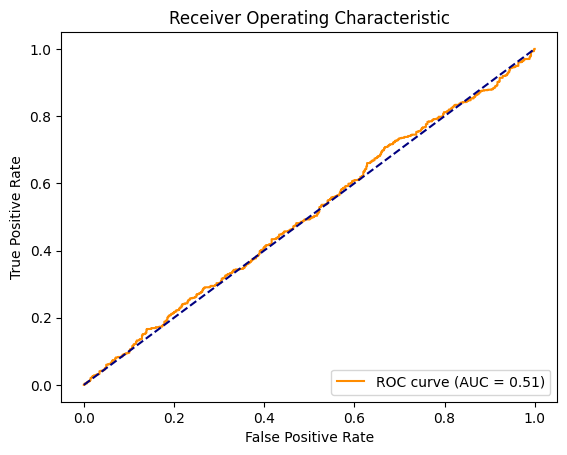

Актив: usd_rub
Горизонт прогноза: t+1


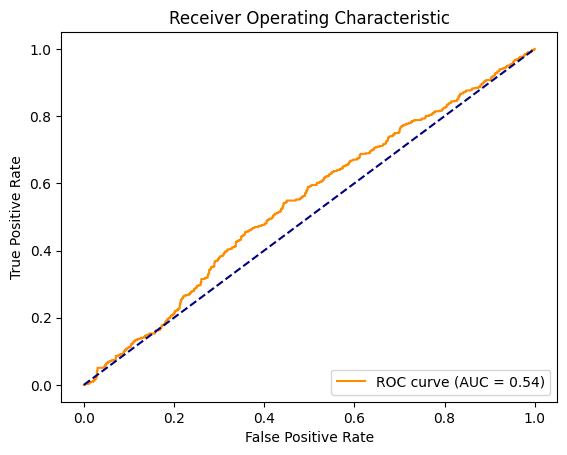

Актив: usd_rub
Горизонт прогноза: t+5


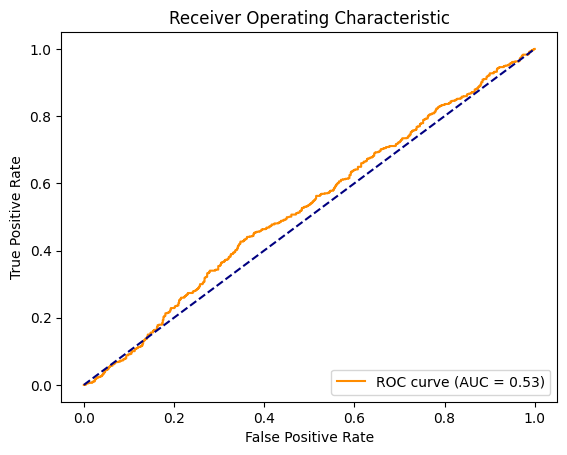

Актив: usd_rub
Горизонт прогноза: t+10


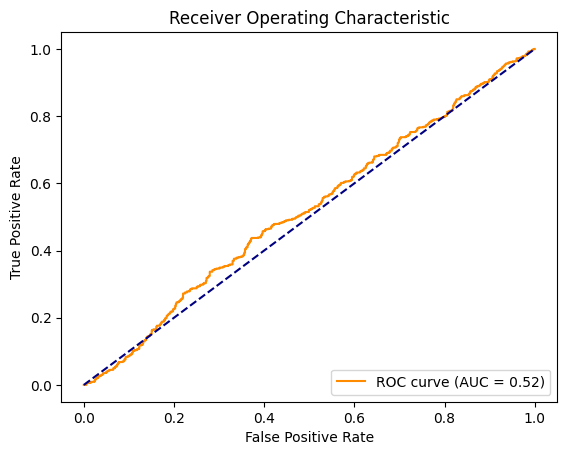

Актив: usd_rub
Горизонт прогноза: t+20


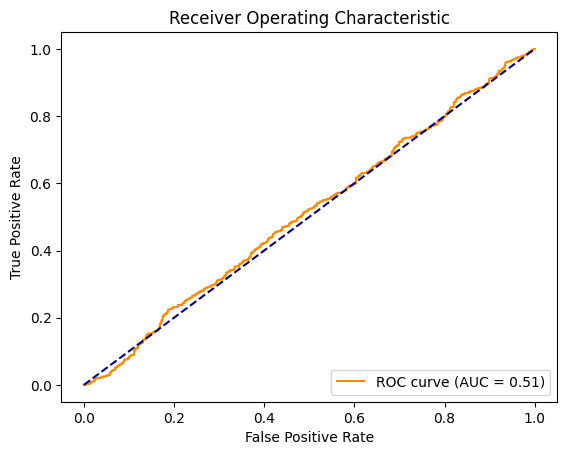

In [142]:
for ticker in test['ticker'].unique():
    for i in [1, 5, 10, 20]:

        print('===========================================')
        print('Актив:', ticker)
        print(f'Горизонт прогноза: t+{i}')
        print('===========================================')
        
        iter_df = test[test['ticker'] == ticker]
        
        fpr, tpr, thresholds = roc_curve(iter_df['target_1'], iter_df[f'prob_{i}'])
        roc_auc = auc(fpr, tpr)
        
        plt.figure()
        plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic')
        plt.legend(loc="lower right")
        plt.show()

# Zero shot - brent

In [101]:
brent = yf.download('BZ=F', start='2020-01-01')['Close'].reset_index().rename(columns={'BZ=F':'price'})
brent

[*********************100%***********************]  1 of 1 completed


Ticker,Date,price
0,2020-01-02,66.250000
1,2020-01-03,68.599998
2,2020-01-06,68.910004
3,2020-01-07,68.269997
4,2020-01-08,65.440002
...,...,...
1589,2026-04-27,108.230003
1590,2026-04-28,111.260002
1591,2026-04-29,118.029999
1592,2026-04-30,114.010002


In [102]:
for lag in range(1, 22):
    brent[f'chg_{lag}d'] = brent['price'].pct_change(lag)

brent['perf_1d'] = brent['price'].shift(-1) / brent['price'] - 1
brent['perf_5d'] = brent['price'].shift(-5) / brent['price'] - 1
brent['perf_10d'] = brent['price'].shift(-10) / brent['price'] - 1
brent['perf_20d'] = brent['price'].shift(-20) / brent['price'] - 1

brent['target_1'] = np.where(brent['perf_1d'] > 0, 1, 0)
brent['target_2'] = np.where(brent['perf_5d'] > 0, 1, 0)
brent['target_3'] = np.where(brent['perf_10d'] > 0, 1, 0)
brent['target_4'] = np.where(brent['perf_20d'] > 0, 1, 0)

del brent['perf_1d'], brent['perf_5d'], brent['perf_10d'], brent['perf_20d']
brent = brent.dropna()

brent

Ticker,Date,price,chg_1d,chg_2d,chg_3d,chg_4d,chg_5d,chg_6d,chg_7d,chg_8d,...,chg_16d,chg_17d,chg_18d,chg_19d,chg_20d,chg_21d,target_1,target_2,target_3,target_4
21,2020-02-03,54.450001,-0.063790,-0.065878,-0.089617,-0.085028,-0.082097,-0.102818,-0.122340,-0.138586,...,-0.167049,-0.167940,-0.202431,-0.209839,-0.206268,-0.178113,0,0,1,0
22,2020-02-04,53.959999,-0.008999,-0.072215,-0.074284,-0.097810,-0.093262,-0.090357,-0.110891,-0.130239,...,-0.169591,-0.174545,-0.175428,-0.209609,-0.216950,-0.213411,1,1,1,0
23,2020-02-05,55.279999,0.024463,0.015243,-0.049519,-0.051638,-0.075740,-0.071080,-0.068105,-0.089142,...,-0.138941,-0.149277,-0.154352,-0.155257,-0.190274,-0.197794,0,1,1,0
24,2020-02-06,54.930000,-0.006331,0.017976,0.008815,-0.055536,-0.057643,-0.081592,-0.076962,-0.074005,...,-0.148240,-0.144392,-0.154663,-0.159706,-0.160605,-0.195401,0,1,1,0
25,2020-02-07,54.470001,-0.008374,-0.014653,0.009451,0.000367,-0.063446,-0.065534,-0.089283,-0.084692,...,-0.148906,-0.155373,-0.151558,-0.161742,-0.166743,-0.167634,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1589,2026-04-27,108.230003,0.027533,0.030075,0.062015,0.099005,0.133536,0.197500,0.088943,0.140103,...,-0.007337,0.069889,-0.085509,-0.040344,-0.038554,0.002037,1,0,0,0
1590,2026-04-28,111.260002,0.027996,0.056299,0.058913,0.091748,0.129773,0.165270,0.231025,0.119429,...,0.013574,0.020453,0.099842,-0.059907,-0.013478,-0.011637,1,0,0,0
1591,2026-04-29,118.029999,0.060848,0.090548,0.120573,0.123346,0.158179,0.198517,0.236175,0.305931,...,0.080168,0.075248,0.082546,0.166765,-0.002704,0.046551,0,0,0,0
1592,2026-04-30,114.010002,-0.034059,0.024717,0.053405,0.082408,0.085086,0.118732,0.157697,0.194072,...,0.203272,0.043379,0.038626,0.045676,0.127026,-0.036671,0,0,0,0


In [103]:
x_test_new = brent[brent['Date'] > '2021-01-01'][features].to_numpy()
y_test_new = brent[brent['Date'] > '2021-01-01'][targets].to_numpy()

x_test_new_scaled = scaler.transform(x_test_new).clip(-1, 1)

x_test_new_seq = x_test_new_scaled.reshape(x_test_new_scaled.shape[0], 1, x_test_new_scaled.shape[1])
y_test_new_seq = y_test_new.copy()

x_test_new_seq.shape, y_test_new_seq.shape

((1341, 1, 21), (1341, 4))

In [104]:
# ================================================================
# Прогноз на тестовой выборке
# ================================================================

y_pred = model.predict(x_test_new_seq, verbose=1, batch_size=BATCH_SIZE)
y_pred_classes = (y_pred > 0.5).astype("int32")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [105]:
# ================================================================
# Метрики ошибок на тестовой выборке
# ================================================================

print(classification_report(y_test_new_seq, y_pred_classes))

              precision    recall  f1-score   support

           0       0.56      0.54      0.54       725
           1       0.54      0.80      0.64       719
           2       0.53      0.91      0.67       710
           3       0.52      0.95      0.67       696

   micro avg       0.53      0.79      0.64      2850
   macro avg       0.53      0.80      0.63      2850
weighted avg       0.53      0.79      0.63      2850
 samples avg       0.50      0.65      0.53      2850



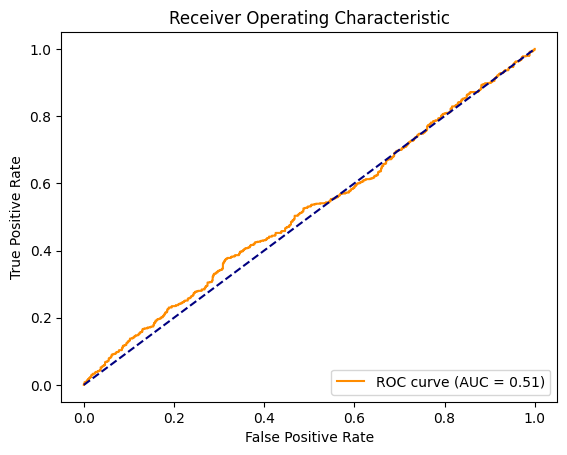

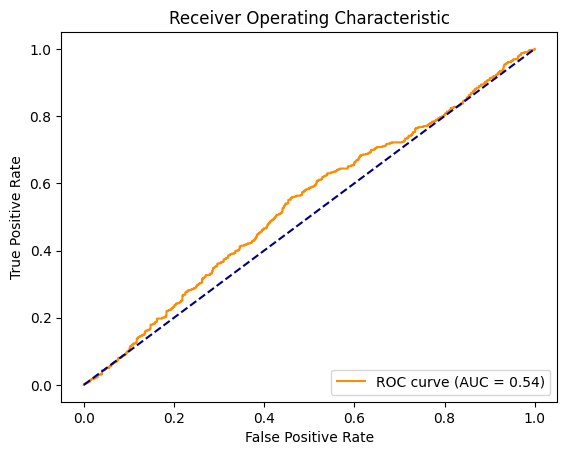

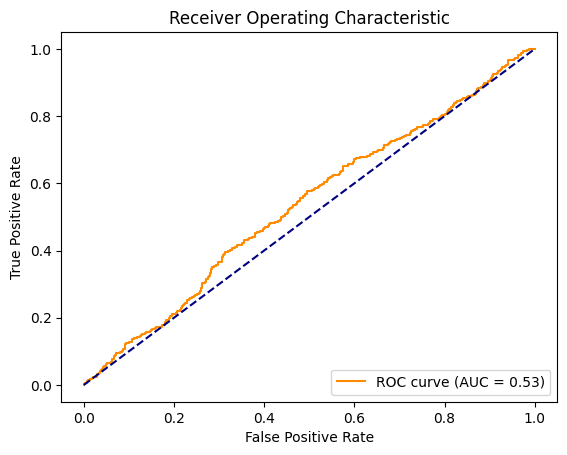

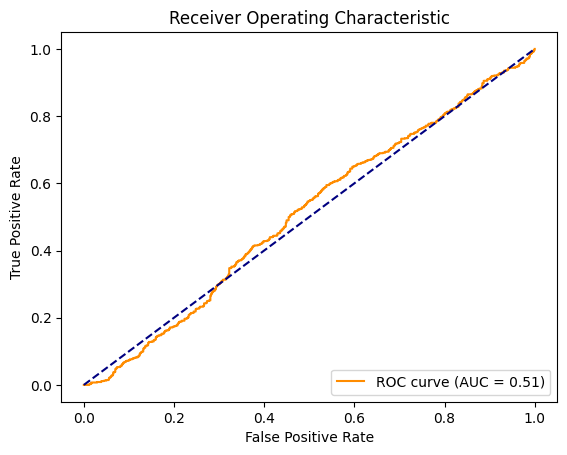

In [106]:
# ================================================================
# ROC-AUC
# ================================================================

for i in range(4):
    fpr, tpr, thresholds = roc_curve(y_test_new_seq[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()

In [108]:
brent_test = brent[brent['Date'] > '2021-01-01']

brent_test['prediction_1'] = y_pred_classes[:, 0]
brent_test['prediction_2'] = y_pred_classes[:, 1]
brent_test['prediction_3'] = y_pred_classes[:, 2]
brent_test['prediction_4'] = y_pred_classes[:, 3]

brent_test

Ticker,Date,price,chg_1d,chg_2d,chg_3d,chg_4d,chg_5d,chg_6d,chg_7d,chg_8d,...,chg_20d,chg_21d,target_1,target_2,target_3,target_4,prediction_1,prediction_2,prediction_3,prediction_4
253,2021-01-04,51.090000,-0.013707,-0.004869,0.000000,0.004522,-0.003899,-0.002148,0.020168,0.003536,...,0.048861,0.058860,1,1,1,1,1,1,1,1
254,2021-01-05,53.599998,0.049129,0.034749,0.044020,0.049129,0.053873,0.045038,0.046875,0.070287,...,0.088325,0.100390,1,1,1,1,0,1,1,1
255,2021-01-06,54.299999,0.013060,0.062830,0.048263,0.057655,0.062830,0.067637,0.058686,0.060547,...,0.112933,0.102538,1,1,1,1,0,1,1,1
256,2021-01-07,54.380001,0.001473,0.014552,0.064396,0.049807,0.059213,0.064396,0.069210,0.060246,...,0.113432,0.114573,1,1,1,1,0,1,1,1
257,2021-01-08,55.990002,0.029606,0.031123,0.044590,0.095909,0.080888,0.090573,0.095909,0.100865,...,0.145927,0.146396,0,0,0,1,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1589,2026-04-27,108.230003,0.027533,0.030075,0.062015,0.099005,0.133536,0.197500,0.088943,0.140103,...,-0.038554,0.002037,1,0,0,0,0,0,1,1
1590,2026-04-28,111.260002,0.027996,0.056299,0.058913,0.091748,0.129773,0.165270,0.231025,0.119429,...,-0.013478,-0.011637,1,0,0,0,0,0,1,1
1591,2026-04-29,118.029999,0.060848,0.090548,0.120573,0.123346,0.158179,0.198517,0.236175,0.305931,...,-0.002704,0.046551,0,0,0,0,0,0,1,1
1592,2026-04-30,114.010002,-0.034059,0.024717,0.053405,0.082408,0.085086,0.118732,0.157697,0.194072,...,0.127026,-0.036671,0,0,0,0,0,1,1,1


# Zero shot - BTC

In [114]:
btc = yf.download('BTC-USD', start='2020-01-01')['Close'].reset_index().rename(columns={'BTC-USD':'price'})
btc

[*********************100%***********************]  1 of 1 completed


Ticker,Date,price
0,2020-01-01,7200.174316
1,2020-01-02,6985.470215
2,2020-01-03,7344.884277
3,2020-01-04,7410.656738
4,2020-01-05,7411.317383
...,...,...
2308,2026-04-27,77366.625000
2309,2026-04-28,76350.671875
2310,2026-04-29,75776.132812
2311,2026-04-30,76304.320312


In [115]:
for lag in range(1, 22):
    btc[f'chg_{lag}d'] = btc['price'].pct_change(lag)

btc['perf_1d'] = btc['price'].shift(-1) / btc['price'] - 1
btc['perf_5d'] = btc['price'].shift(-5) / btc['price'] - 1
btc['perf_10d'] = btc['price'].shift(-10) / btc['price'] - 1
btc['perf_20d'] = btc['price'].shift(-20) / btc['price'] - 1

btc['target_1'] = np.where(btc['perf_1d'] > 0, 1, 0)
btc['target_2'] = np.where(btc['perf_5d'] > 0, 1, 0)
btc['target_3'] = np.where(btc['perf_10d'] > 0, 1, 0)
btc['target_4'] = np.where(btc['perf_20d'] > 0, 1, 0)

del btc['perf_1d'], btc['perf_5d'], btc['perf_10d'], btc['perf_20d']
btc = btc.dropna()

btc

Ticker,Date,price,chg_1d,chg_2d,chg_3d,chg_4d,chg_5d,chg_6d,chg_7d,chg_8d,...,chg_16d,chg_17d,chg_18d,chg_19d,chg_20d,chg_21d,target_1,target_2,target_3,target_4
21,2020-01-22,8680.875977,-0.007434,0.002684,-0.002914,-0.029290,-0.027793,-0.004919,-0.014322,-0.016639,...,0.117342,0.171300,0.171404,0.181894,0.242705,0.205648,0,1,1,1
22,2020-01-23,8406.515625,-0.031605,-0.038804,-0.029006,-0.034427,-0.059969,-0.058519,-0.036368,-0.045475,...,0.029744,0.082028,0.134281,0.134382,0.144540,0.203429,1,1,1,1
23,2020-01-24,8445.434570,0.004630,-0.027122,-0.034354,-0.024511,-0.029957,-0.055617,-0.054161,-0.031907,...,0.045245,0.034512,0.087038,0.139532,0.139634,0.149839,0,1,1,1
24,2020-01-25,8367.847656,-0.009187,-0.004600,-0.036060,-0.043226,-0.033473,-0.038868,-0.064293,-0.062850,...,0.062035,0.035642,0.025008,0.077051,0.129063,0.129164,1,1,1,1
25,2020-01-26,8596.830078,0.027365,0.017926,0.022639,-0.009682,-0.017044,-0.007024,-0.012567,-0.038688,...,0.052688,0.091097,0.063982,0.053057,0.106524,0.159960,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2308,2026-04-27,77366.625000,-0.016412,-0.003162,-0.001145,-0.011529,-0.010696,0.013279,0.019692,0.047528,...,0.059029,0.060121,0.078013,0.087781,0.075422,0.123538,0,0,0,0
2309,2026-04-28,76350.671875,-0.013132,-0.029328,-0.016252,-0.014262,-0.024509,-0.023687,-0.000028,0.006302,...,0.079109,0.045123,0.046200,0.063857,0.073496,0.061300,0,0,0,0
2310,2026-04-29,75776.132812,-0.007525,-0.020558,-0.036632,-0.023655,-0.021679,-0.031849,-0.031034,-0.007552,...,0.017339,0.070989,0.037258,0.038327,0.055851,0.065418,1,0,0,0
2311,2026-04-30,76304.320312,0.006970,-0.000607,-0.013731,-0.029917,-0.016849,-0.014860,-0.025101,-0.024280,...,0.028615,0.024430,0.078454,0.044488,0.045565,0.063211,1,0,0,0


In [116]:
x_test_new = btc[btc['Date'] > '2021-01-01'][features].to_numpy()
y_test_new = btc[btc['Date'] > '2021-01-01'][targets].to_numpy()

x_test_new_scaled = scaler.transform(x_test_new).clip(-1, 1)

x_test_new_seq = x_test_new_scaled.reshape(x_test_new_scaled.shape[0], 1, x_test_new_scaled.shape[1])
y_test_new_seq = y_test_new.copy()

x_test_new_seq.shape, y_test_new_seq.shape

((1946, 1, 21), (1946, 4))

In [117]:
# ================================================================
# Прогноз на тестовой выборке
# ================================================================

y_pred = model.predict(x_test_new_seq, verbose=1, batch_size=BATCH_SIZE)
y_pred_classes = (y_pred > 0.5).astype("int32")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [118]:
# ================================================================
# Метрики ошибок на тестовой выборке
# ================================================================

print(classification_report(y_test_new_seq, y_pred_classes))

              precision    recall  f1-score   support

           0       0.49      0.50      0.50       969
           1       0.51      0.71      0.60      1010
           2       0.53      0.84      0.65      1019
           3       0.52      0.91      0.66       994

   micro avg       0.52      0.74      0.61      3992
   macro avg       0.51      0.74      0.60      3992
weighted avg       0.51      0.74      0.60      3992
 samples avg       0.47      0.61      0.49      3992



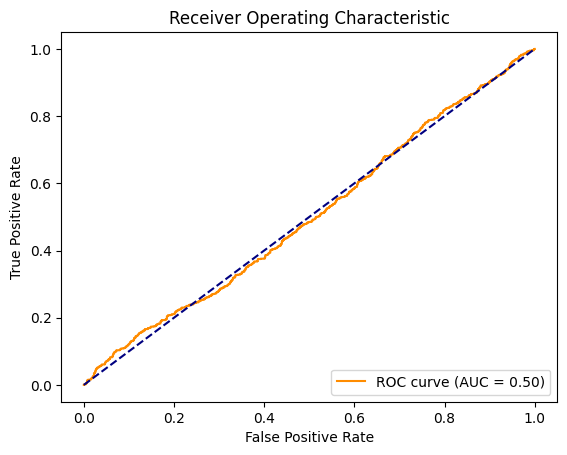

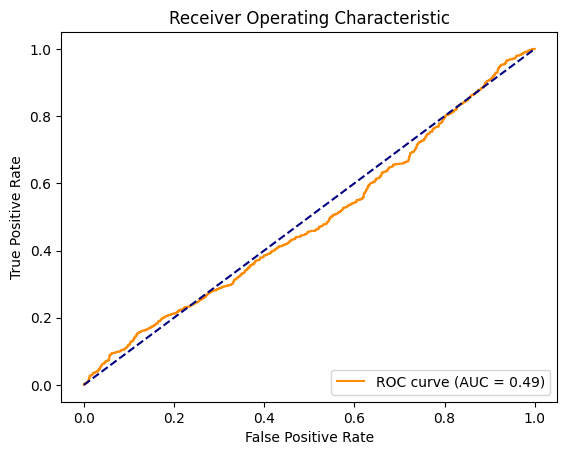

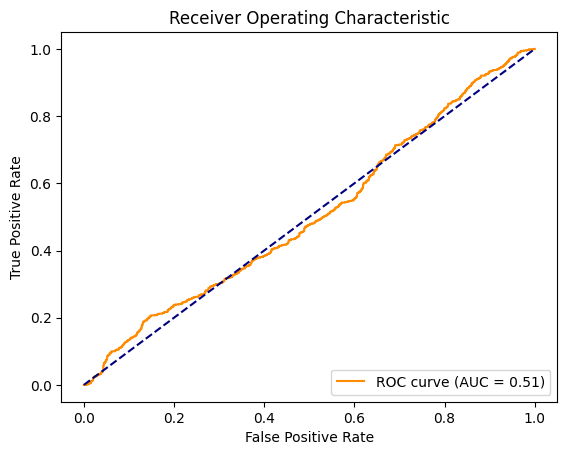

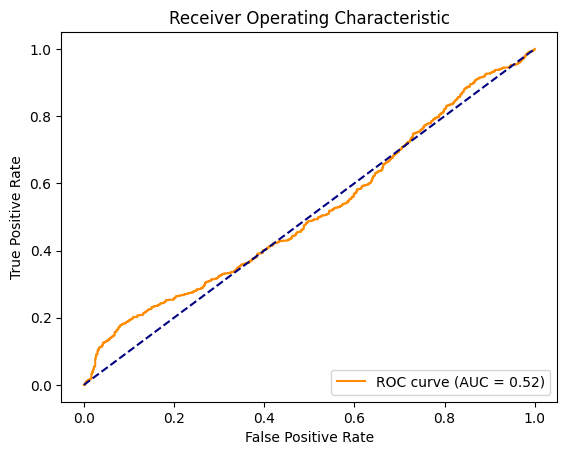

In [119]:
# ================================================================
# ROC-AUC
# ================================================================

for i in range(4):
    fpr, tpr, thresholds = roc_curve(y_test_new_seq[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()

In [120]:
btc_test = btc[btc['Date'] > '2021-01-01']

btc_test['prediction_1'] = y_pred_classes[:, 0]
btc_test['prediction_2'] = y_pred_classes[:, 1]
btc_test['prediction_3'] = y_pred_classes[:, 2]
btc_test['prediction_4'] = y_pred_classes[:, 3]

btc_test

Ticker,Date,price,chg_1d,chg_2d,chg_3d,chg_4d,chg_5d,chg_6d,chg_7d,chg_8d,...,chg_20d,chg_21d,target_1,target_2,target_3,target_4,prediction_1,prediction_2,prediction_3,prediction_4
367,2021-01-02,32127.267578,0.093726,0.107771,0.113946,0.174138,0.186173,0.222857,0.215237,0.302556,...,0.678332,0.708565,1,1,1,1,1,1,1,1
368,2021-01-03,32782.023438,0.020380,0.116016,0.130348,0.136648,0.198067,0.210347,0.247779,0.240004,...,0.703259,0.712536,0,1,1,0,1,1,1,1
369,2021-01-04,31971.914062,-0.024712,-0.004836,0.088437,0.102414,0.108560,0.168460,0.180437,0.216944,...,0.646587,0.661168,1,1,1,1,1,1,1,1
370,2021-01-05,33992.429688,0.063197,0.036923,0.058055,0.157222,0.172083,0.178617,0.242303,0.255037,...,0.595095,0.750646,1,1,1,0,1,1,1,1
371,2021-01-06,36824.363281,0.083311,0.151772,0.123310,0.146203,0.253632,0.269730,0.276808,0.345800,...,0.614738,0.727984,1,0,0,0,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2308,2026-04-27,77366.625000,-0.016412,-0.003162,-0.001145,-0.011529,-0.010696,0.013279,0.019692,0.047528,...,0.075422,0.123538,0,0,0,0,1,1,1,1
2309,2026-04-28,76350.671875,-0.013132,-0.029328,-0.016252,-0.014262,-0.024509,-0.023687,-0.000028,0.006302,...,0.073496,0.061300,0,0,0,0,1,1,1,1
2310,2026-04-29,75776.132812,-0.007525,-0.020558,-0.036632,-0.023655,-0.021679,-0.031849,-0.031034,-0.007552,...,0.055851,0.065418,1,0,0,0,1,1,1,1
2311,2026-04-30,76304.320312,0.006970,-0.000607,-0.013731,-0.029917,-0.016849,-0.014860,-0.025101,-0.024280,...,0.045565,0.063211,1,0,0,0,1,1,1,1
